# Dienstag Abend
## Zuerst Bestimmung von lP

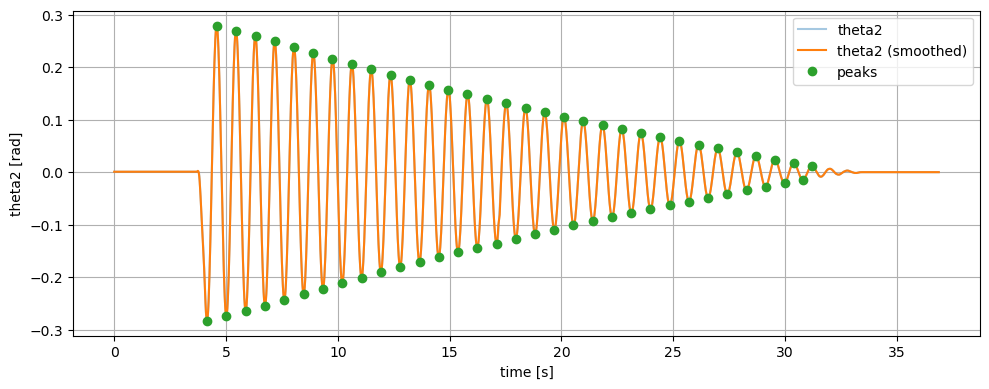

lP gefunden! lP = 0.191605 m


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import find_peaks, savgol_filter

# Parameter 
g = 9.81
L2 = 0.240
lP = 0.1917
mS = 0.0274
mP = 0.0510         # <- 0.0 wenn keine Zusatzmasse montiert ist
m2 = mS + mP
l2 = L2/2
epsilon = 0.01


# --- Pendellänge lP aus Eigenfrequenz (kompakt, nur Peaks; kein FFT) ---

def estimate_omega_from_peaks(t, theta2, plot=True):
    t = np.asarray(t).ravel()
    x = np.asarray(theta2).ravel()

    m = np.isfinite(t) & np.isfinite(x)
    t, x = t[m], x[m]
    idx = np.argsort(t)
    t, x = t[idx], x[idx]

    dt = float(np.median(np.diff(t)))
    x = x - np.median(x)

    win = int(round(0.2 / dt))
    win = max(11, win) | 1  # odd
    x_s = savgol_filter(x, window_length=win, polyorder=3)

    amp_ref = np.percentile(np.abs(x_s), 90)
    prom = max(0.10 * amp_ref, 1e-9)

    # pos + neg peaks -> half-period spacings
    peaks = np.sort(np.r_[find_peaks(x_s, prominence=prom)[0],
                         find_peaks(-x_s, prominence=prom)[0]])
    if peaks.size < 6:
        raise RuntimeError(f"Too few peaks detected ({peaks.size}).")

    dT = np.diff(t[peaks])
    med = np.median(dT)
    dT = dT[(dT > 0.5*med) & (dT < 1.5*med)]
    if dT.size < 4:
        raise RuntimeError("Peak spacings too inconsistent.")

    T = 2.0 * float(np.mean(dT))
    omega = 2.0 * np.pi / T

    if plot:
        plt.figure(figsize=(10, 4))
        plt.plot(t, x, label="theta2", alpha=0.4)
        plt.plot(t, x_s, label="theta2 (smoothed)")
        plt.plot(t[peaks], x_s[peaks], "o", label="peaks")
        plt.grid(True); plt.xlabel("time [s]"); plt.ylabel("theta2 [rad]")
        plt.legend(); plt.tight_layout(); plt.show()

    return omega

# CSV einlesen
df = pd.read_csv("messungIdentPendulum.csv")
t = df["time"].values
theta2 = df["F: theta2"].values
theta2dot = df["F: theta2dot"].values
dt = t[1] - t[0]

omega = estimate_omega_from_peaks(t, theta2, plot=True)

# Mitternachtsformel für lP
a = mP * omega**2
bq = -mP * g
c = (1/3) * mS * L2**2 * omega**2 - mS * g * (L2 / 2)

D = bq**2 - 4*a*c
if D < 0:
    raise ValueError("Keine reelle Lösung für lP (Diskriminante < 0)")

lP_1 = (-bq + np.sqrt(D)) / (2*a)
lP_2 = (-bq - np.sqrt(D)) / (2*a)
lP_candidates = [l for l in (lP_1, lP_2) if 0 < l < L2]
if not lP_candidates:
    raise ValueError("Keine physikalisch sinnvolle Lösung gefunden")

lP_ident = lP_candidates[0]
print(f"lP gefunden! lP = {lP_ident:.6f} m")

# neues J2_hat:
J2_hat = (1/12) * mS * L2**2 + mS * l2**2 + mP * lP_ident**2


## Dann bestimmen von µh und µv über mathematische Optimierung und kostenfunktion

In [2]:
# Optional: Fenster wie bei dir
mask = (t >= 5) & (t <= 35)
t = t[mask]
theta2_meas = theta2_meas[mask]
dtheta2_meas = dtheta2_meas[mask]

# ==============================
# Bekannte Parameter
# ==============================
g = 9.81
L2 = 0.240
mS = 0.0274
mP = 0.0510
epsilon = 0.01
l2 = L2 / 2.0

# >>> HIER dein bereits identifiziertes lp einsetzen:
#lP_ident = 0.1917  # <-- ersetzen durch deinen Wert

m2 = mS + mP
l2_eff = (mS * l2 + mP * lP_ident) / m2
J2 = (1.0/3.0) * mS * L2**2 + mP * lP_ident**2  # Trägheit um Gelenk

dt = float(np.median(np.diff(t)))

# ==============================
# Reibung nach Angabe (stückweise + kubische Glättung)
# b(v)= mu_V*v +/- mu_H  (|v|>=eps)
# b(v)= phi(v)           (|v|<eps)
# ==============================
def friction_spec(v, mu_V, mu_H, eps=epsilon):
    if v <= -eps:
        return mu_V * v - mu_H
    if v >= eps:
        return mu_V * v + mu_H
    return ((3.0*mu_H)/(2.0*eps) + 0.5*mu_V) * v - (mu_H/(2.0*eps**3)) * (v**3)

# ==============================
# ODE: Rotor fix, linearisierte Gravitation (sin(theta)≈theta)
# y = [theta2, dtheta2]
# ==============================
def pendulum_ode(t_, y, mu_V2, mu_H2):
    theta, dtheta = y
    b = friction_spec(dtheta, mu_V2, mu_H2, epsilon)
    ddtheta = -(m2 * l2_eff * g * theta + b) / J2
    return [dtheta, ddtheta]

# ==============================
# Residuen für least_squares
# p = [mu_V2, mu_H2]
# ==============================
def residuals(p):
    mu_V2, mu_H2 = p

    y0 = [float(theta2_meas[0]), float(dtheta2_meas[0])]

    sol = solve_ivp(
        pendulum_ode,
        (float(t[0]), float(t[-1])),
        y0,
        args=(mu_V2, mu_H2),
        t_eval=t,
        method="RK45",
        rtol=1e-7,
        atol=1e-9,
        max_step=dt,   # folgt der Messabtastung
    )

    theta_sim = sol.y[0]
    dtheta_sim = sol.y[1]

    # optional: Geschwindigkeit etwas weniger gewichten
    w_dtheta = 1.0

    return np.concatenate([
        theta_sim - theta2_meas,
        w_dtheta * (dtheta_sim - dtheta2_meas),
    ])

# ==============================
# Startwerte + Bounds (physikalisch: mu>=0)
# ==============================
p0 = np.array([1.332e-5, 3.018e-4])    # [mu_V2, mu_H2]
lb = np.array([0.0, 0.0])
ub = np.array([1e-2, 1e-1])

res = least_squares(residuals, p0, bounds=(lb, ub), method="trf")

mu_V2_opt, mu_H2_opt = res.x

print("Optimierte Parameter:")
print(f"mu_V2 = {mu_V2_opt:.6e}")
print(f"mu_H2 = {mu_H2_opt:.6e}")
print("success:", res.success, "-", res.message)
print("cost:", res.cost, "(= 0.5*||r||^2)")

NameError: name 'theta2_meas' is not defined

## anschließendes Plotten der Paramater µh und µv mit dem limitierten Zustandsraummodel

In [ ]:
# ==========================================================
# Reibung: Wie aus der Angabe (stückweise + kubischer Übergang)
# ==========================================================
def friction(v: float, mu_V: float, mu_H: float) -> float:
    if v <= -epsilon:
        return mu_V * v - mu_H
    if v >= epsilon:
        return mu_V * v + mu_H
    c1 = 3.0 * mu_H / (2.0 * epsilon) + 0.5 * mu_V
    c3 = -mu_H / (2.0 * epsilon**3)
    return c3 * v**3 + c1 * v

# ==========================================================
# Pendel-Zustandsraummodell (Rotor fix)
# x = [theta2, theta2_dot]
# ==========================================================
USE_LINEARIZED_GRAVITY = True  # True: sin(theta)≈theta, False: sin(theta)

def pendulum_dynamics(t, x):
    theta2, theta2_dot = x
    b2 = friction(theta2_dot, mu_V2, mu_H2)

    grav = (m2 * l2_eff * g) * (theta2 if USE_LINEARIZED_GRAVITY else np.sin(theta2))

    # ddtheta2 = -(grav + b2)/J2
    theta2_ddot = -(grav + b2) / J2_hat

    return [theta2_dot, theta2_ddot]

# ==========================================================
# Simulation
# ==========================================================
t_span = (0.0, 37.0)
x0 = [-0.27724555167930104, 0.3187903256803709]  # nur theta2, theta2dot

sol1 = solve_ivp(
    pendulum_dynamics,
    t_span,
    x0,
    rtol=1e-6,
    atol=1e-9,
    max_step=1e-2,
)

# (Optional) zweite Simulation mit optimierten Reibwerten
mu_V2 = mu_V2_opt
mu_H2 = mu_H2_opt
sol2 = solve_ivp(
    pendulum_dynamics,       # Funktion von der die Ableitung berechnet werden soll
    t_span,                # Integrationsbereich
    x0,                    # Anfangszustand
    rtol=1e-6,             # relative Toleranz
    atol=1e-9,             # absolute Toleranz
    max_step=1e-2          # Schrittweite des adaptiven Solvers
)

# ==========================================================
# Plot + CSV Vergleich
# ==========================================================
df = pd.read_csv("messungIdentPendulum.csv")
t_m = df["time"].values
theta2_m = df["F: theta2"].values

# optional schneiden wie vorher
t_m = t_m[210:]
theta2_m = theta2_m[210:]

plt.figure(figsize=(10, 6))
plt.plot(sol1.t + 4.18, sol1.y[0],"--", label="theta2 (sim, rotor fix)")
plt.plot(sol2.t + 4.18, sol2.y[0],"--", label="theta2 (sim, rotor fix, µopt)")
plt.plot(t_m, theta2_m,"--", label="theta2 (messdaten)")
plt.ylabel("Angle [rad]")
plt.xlabel("t [s]")
plt.legend()
plt.grid(True)
plt.show()